<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

# Análisis y procesamiento de señales
## Augusto Ojeda-Matias Carbajal TS5: Estimación espectral: Ancho de banda de señales reales

### Introducción teórica


El análisis espectral es una herramienta fundamental para caracterizar el contenido en frecuencia de una señal, es fundamental para realizar estos análisis identificar entre señales de energia y señales de potencia ya que este criterio determina el tipo de análisis espectral a realizar. Una señal de energia es aquella que tiene energia finita y potencia promedio nula. Su energia total se define como:
$$E= \sum_{n=-\infty}^{\infty}|X[n]|^{2} (1)$$ Estas señales suelen ser no periodicas y de duracion infinita, como impulsos. Por otro lado, una señal de potencia posee potencia promedio infinita y se define como $$P=\lim_{N->\infty} \frac{1}{2N+1}\sum_{n=-N}^{N}|X[n]|^{2} (2)$$ Estas señales suelen ser periodicas o estacionarias en el tiempo como las senoideales o el ruido blanco.



En particular nos interesa estimar la densidad espectral de potencia (DSP) esta describe como se distribuye la potencia de una señal en función de la frecuencia, permitiendo identificar los componentes energeticos dominantes y determinar el ancho de banda efectivo del sistema o señal bajo estudio. La DSP esta relacionado con la funcion de autocorrelacion $R_x(r)$ mediante la transformada de Fourier:
$$S_x(f)= F{R_x(r)}=\int_{-\infty}^{\infty}R_x(r)e^{-j2\pi fr}dr (3)$$. Existen diversos métodos para estimar la densidad espectral de potencia a partir de señales discretas y finitas. Entre los mas utilizados y los que se utilizaran en este informe son el metodo de Welch y Blackman-Tukey.

El metodo de Welch es un estimador de densidad espectral de potencia que busca reducir la varianza de la estimación. Consiste en dividir la señal en segmentos (solapados o no), aplicar una ventana de ponderación a cada segmento (como Hamming o Hann), calcular su transformacion rápida de fourier (FFT) y promediar las potencias resultantes:
$$S_x(f)=\frac{1}{K}\ \sum_{k=1}^{K}(4)\frac{1}{U}|FFT \{{w|n|x_k|n|}\}|^{2}\ (4) $$
Donde K es el número de segmentos, $w[n]$ es la ventana aplicada y U es un factor de normalización, este metodo reduce la varianza del espectro estimado, aunque sacrifica algo de resolución espectral. Siempre se puede sumar zero-padding a este metodo para mejorar la iteración. 

El metodo de Blackman-Tukey se basa en estimar primero la autocorrelacion $R_xx[m]$ de la señal y luego trucarla mediante una ventana w[m]. La estimacion de la DSP se obtiene mediante:
$$S_x(f)=\sum_{m=-M}^{M} w[m]R_xx[m]e^{-j2 \pi fm} (5) $$ Este metodo presenta menor sesgo que Welch , pero una mayor varianza por lo que resulta mas adecuado para señales estacionarias y mediciones prolongadas.

El ancho de banada de una señal se define como el rango de frecuencias donde se concentra la mayor parte de la potencia de la señal. Existen diferentes criterios para definirlo, si el ancho de banda es de -3db
$$B=f_2-f_1(6)$$ donde $$S_x(f_1)=S_x(f_2)=\frac{S_{x max}}{2}(7)$$ o se puede definir por ancho de banda efectivo o equivalente $$B_{ef}=\frac{\int_{0}^{\infty}S_x(f)df}{S_{xmax}}(8)$$ En la práctica, el ancho de banda indica la resolución o capacidad de transmisión del sistema, asi como la región espectral significativa de la señal.

### Análisis, desarollo y Discusión


Para poder realizar tanto las estimaciones de densidad espectral como ancho de banda se utilizaron 3 señales reales, un EDC, un PPG y la cancion de la cucaracha, para introducir las señales se utilizaron las siguientes funciones  

In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
from numpy.fft import fft
#cte universales 
fs_ecg = 1000 # Hz
fs_ppg = 400 # Hz

#funciones de ingreso
#Ecg sin ruido 
ecg_one_lead = np.load('ecg_sin_ruido.npy')
Necg=ecg_one_lead.shape[0]
#La cucaracha
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
Ncuca=wav_data.shape[0]
#PPG
ppg = np.load('ppg_sin_ruido.npy')
Nppg=ppg.shape[0]

Para cada una de nuestras señales no resulta relevante aplicar las ecuaciones (4) y (5) de forma directa. Para poder utilizarlas correctamente, primero es necesario definir una ventana adecuada.

En el caso del método de Welch, la bibliografía recomienda emplear la ventana de Hann, tanto para la señal de ECG como para la de PPG y la señal de audio (canción). En cambio, para el método de Blackman-Tukey, la ventana recomendada es la ventana de Bartlett (también conocida como ventana triangular).

Una vez seleccionadas las ventanas apropiadas para cada método, el siguiente paso consiste en determinar el número de promedios a utilizar en el método de Welch. Para ello, se toma como referencia el espectrograma obtenido mediante el método de Blackman-Tukey, que permite orientar la elección del número de segmentos más adecuado para el análisis.

Text(0.5, 1.0, 'Figura[1]: ECG - Blackman-Tukey')

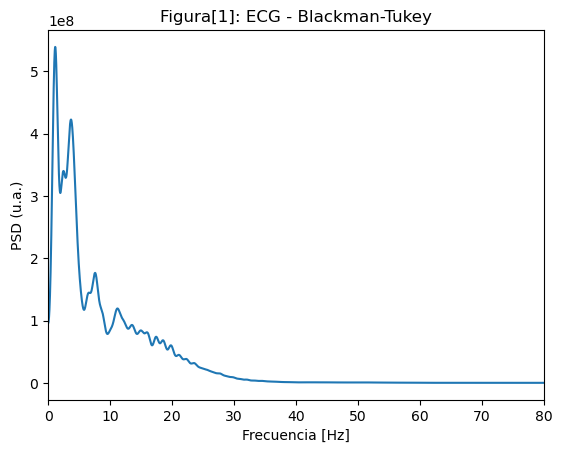

In [2]:
#blackman-tuky ECG 
#Hago autocorrelacion
Ecgxx = ecg_one_lead - np.mean(ecg_one_lead)
Recg=sig.correlate(Ecgxx,Ecgxx, mode='full')/Necg
lagsecg = np.arange(-Necg+1, Necg)
centerecg = len(Recg)//2
M= int(1.0 * fs_ecg)
Recg_seg = Recg[centerecg-M : centerecg+M+1]
#ventaneo por la ventana triangular
Recgventaneada=Recg_seg*sig.windows.bartlett(2*M+1)   
#le calculo la FFT
FFTECG=fft(Recgventaneada,axis=0, n=4*Necg)

half = 4*Necg//2
fEcg = np.linspace(0, fs_ecg/2, half, endpoint=False)

plt.figure()
plt.plot(fEcg, np.abs(FFTECG[:half]))   
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD (u.a.)")
plt.xlim([0, 80])                 
plt.title("Figura[1]: ECG - Blackman-Tukey")

Al analizar la $Figura [1]$, se observa que el aspecto más relevante es conservar los tres valles principales del espectro. El objetivo a partir de este punto es definir un número adecuado de promedios que permita reducir la varianza de la estimación sin perder la resolución espectral ni desdibujar los picos principales de la señal. Se definió la estimación espectral mediante el método de Welch de la siguiente manera: se variaron los números de promedios entre 15, 25 y 35 con el objetivo de analizar el efecto sobre la varianza de la estimación. Además, se buscó que la cantidad de puntos de cada iteración fuera superior a 1000, ajustando para ello el zero-padding, el cual se incrementó o disminuyó según fuera necesario.

cantidad: 2000


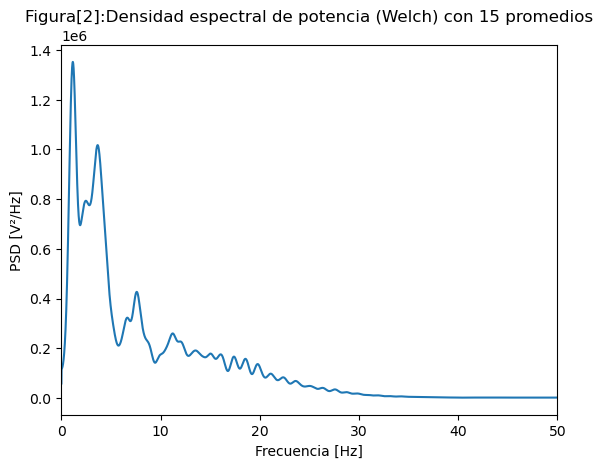

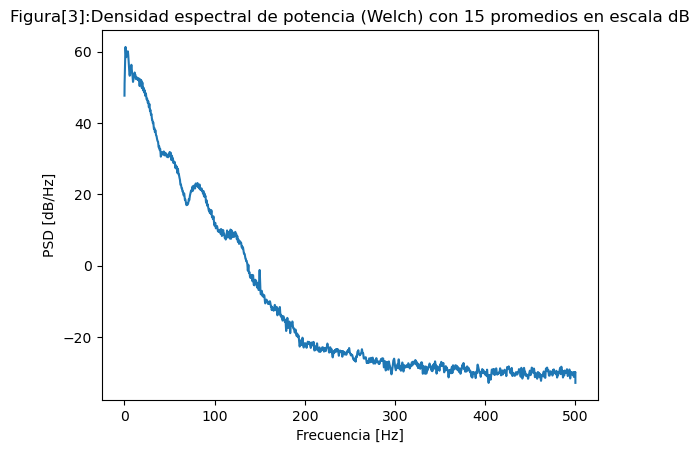

In [21]:
cpECG=15 #cantidad de promedio
npersegECG=ecg_one_lead.shape[0] // cpECG
print("cantidad:",npersegECG)
nfft=100*npersegECG
win='hann'
tWECGSR_ECG,WECGSR_ECG=sig.welch(ecg_one_lead,fs=fs_ecg,window=win,nperseg=npersegECG,nfft=nfft)
plt.figure()
plt.plot(tWECGSR_ECG,(WECGSR_ECG))
plt.xlim(0,50)
plt.title("Figura[2]:Densidad espectral de potencia (Welch) con 15 promedios" )
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWECGSR_ECG,10*np.log10(WECGSR_ECG))
plt.title("Figura[3]:Densidad espectral de potencia (Welch) con 15 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show()

cantidad: 1200


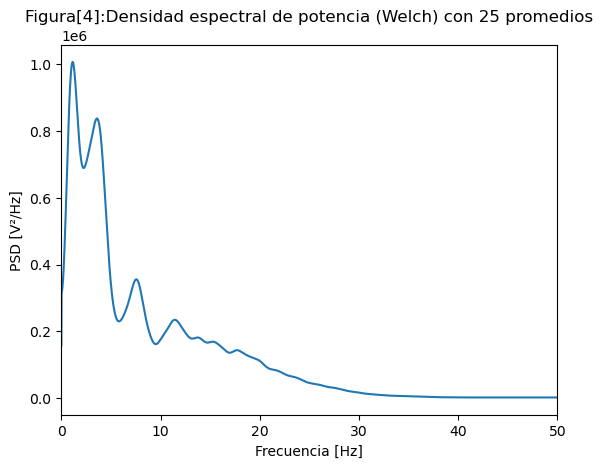

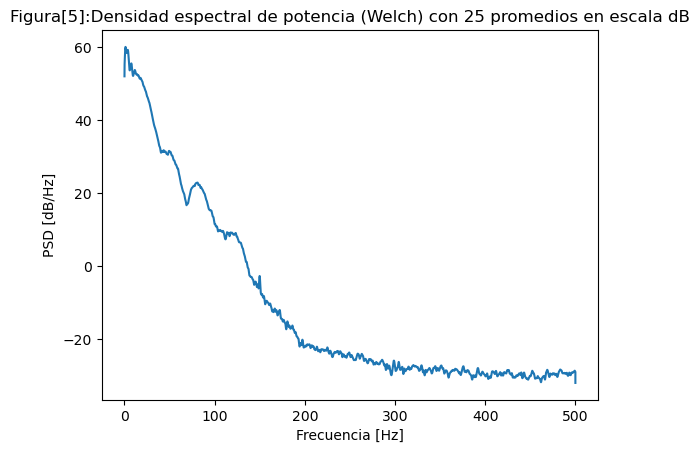

In [52]:
cpECG=25 #cantidad de promedio
npersegECG=ecg_one_lead.shape[0] // cpECG
print("cantidad:",npersegECG)
nfft=100*npersegECG
win='hann'
tWECGSR_ECG,WECGSR_ECG=sig.welch(ecg_one_lead,fs=fs_ecg,window=win,nperseg=npersegECG,nfft=nfft)
plt.figure()
plt.plot(tWECGSR_ECG,(WECGSR_ECG))
plt.xlim(0,50)
plt.title("Figura[4]:Densidad espectral de potencia (Welch) con 25 promedios")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWECGSR_ECG,10*np.log10(WECGSR_ECG))
plt.title("Figura[5]:Densidad espectral de potencia (Welch) con 25 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show()

cantidad: 857


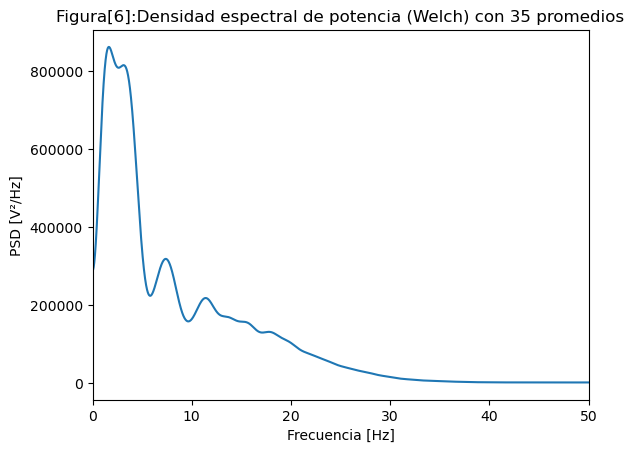

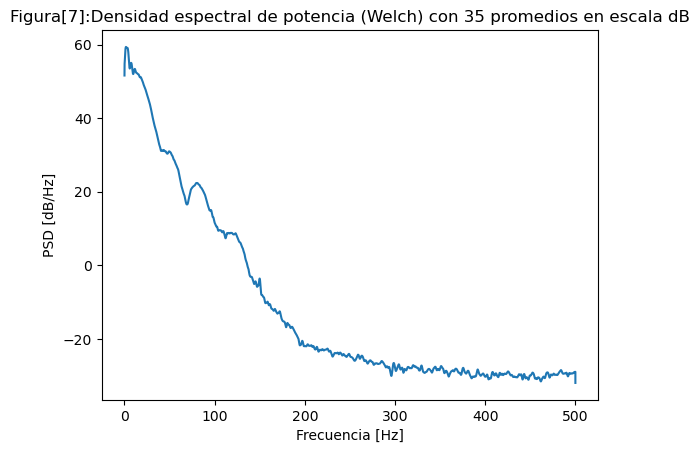

In [5]:
cpECG=35 #cantidad de promedio
npersegECG=ecg_one_lead.shape[0] // cpECG
print("cantidad:",npersegECG)
nfft=100*npersegECG
win='hann'
tWECGSR_ECG,WECGSR_ECG=sig.welch(ecg_one_lead,fs=fs_ecg,window=win,nperseg=npersegECG,nfft=nfft)
plt.figure()
plt.plot(tWECGSR_ECG,(WECGSR_ECG))
plt.xlim(0,50)
plt.title("Figura[6]:Densidad espectral de potencia (Welch) con 35 promedios")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWECGSR_ECG,10*np.log10(WECGSR_ECG))
plt.title("Figura[7]:Densidad espectral de potencia (Welch) con 35 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show()

Al comparar las Figuras [1], [2], [4] y [6], se observa que la Figura [2] presenta una forma espectral más similar a la de la Figura [1]. Esto resulta coherente, ya que al incrementar la cantidad de promedios en el método de Welch, las componentes no correladas —como el ruido— tienden a cancelarse, reduciendo la varianza de la estimación.

Asimismo, al analizar las Figuras [3], [5] y [7], se verifica esta tendencia: al aumentar el número de promedios, los espectros en escala dB se muestran más estables y definidos, dado que el promediado atenúa las fluctuaciones aleatorias y resalta las frecuencias coherentes de la señal. Este comportamiento coincide con la teoría del método de Welch, donde se busca un compromiso entre varianza y resolución espectral para obtener una estimación confiable de la densidad espectral de potencia. Para confirmar esto, vamos a realizar el mismo analisis con la cancion de la cucaracha, variando los promedio para welch entre 10, 20 y 30 a ver si vemos lo mismos efectos: 

Text(0.5, 1.0, 'Figura[8]: La cucaracha - Blackman-Tukey')

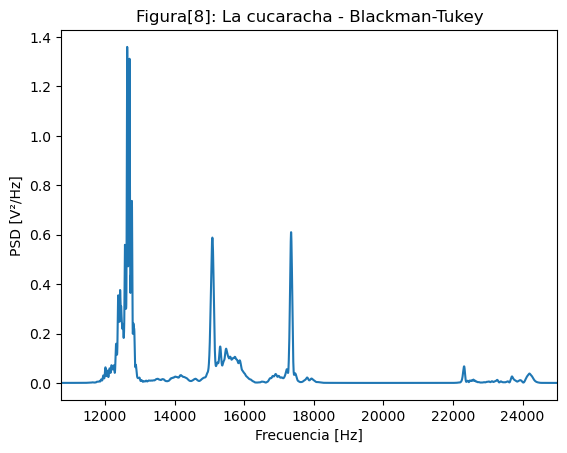

In [55]:
#Blackman-turkey 
#Hago autocorrelacion
y = wav_data
if y.ndim > 1:
    y = y[:, 0]
y = y.astype(float) - np.mean(y)

Ncu = len(y)
Rcu = sig.correlate(y, y, mode='full') / Ncu          # biased
center_cu = len(Rcu) // 2

# elegir M en tiempo -> 0.5 s (ejemplo razonable para audio)
M_des_cu = int(0.5 * fs_audio)
# limitar M por los datos
M_cu = min(M_des_cu, Ncu-1, center_cu, len(Rcu) - center_cu - 1)

Rcu_seg = Rcu[center_cu - M_cu : center_cu + M_cu + 1]
w_cu = sig.windows.bartlett(len(Rcu_seg))
Rcu_win = Rcu_seg * w_cu

nfft_cu = 4 * Ncu
PSD_BT_cu = np.abs(np.fft.rfft(Rcu_win, n=nfft_cu))

plt.figure()
plt.plot(np.abs(PSD_BT_cu))
plt.xlim(10750,25000)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.title('Figura[8]: La cucaracha - Blackman-Tukey')

14400


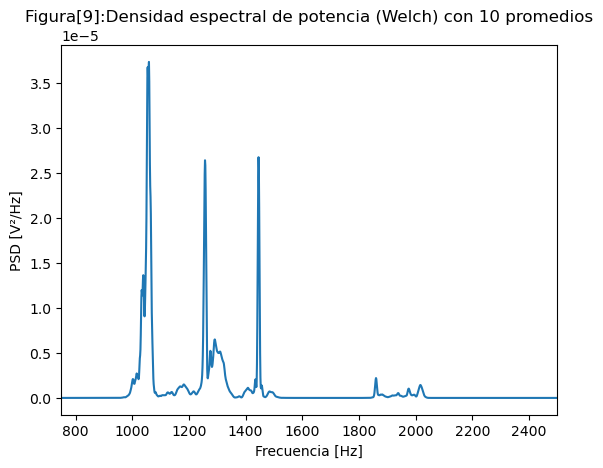

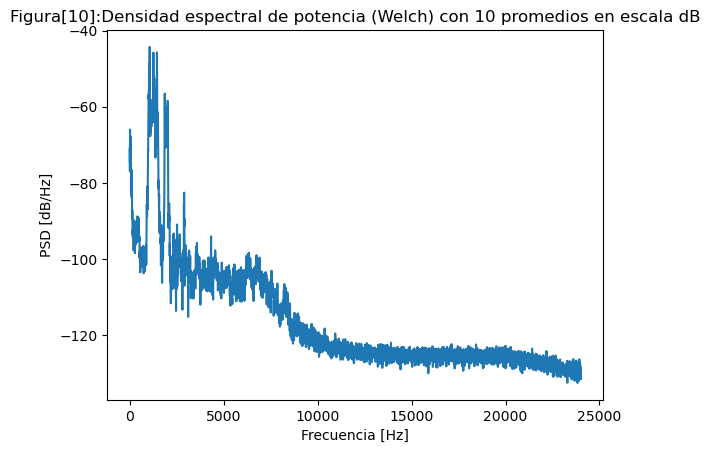

In [7]:
cpcucaracha=10 #cantidad de promedio
npersegcucaracha=wav_data.shape[0] // cpcucaracha
print(npersegcucaracha)
nfftcucaracha=3*npersegcucaracha
win='hann'
tWCuca,WCuca=sig.welch(wav_data,fs=fs_audio,window=win,nperseg=npersegcucaracha,nfft=nfftcucaracha)
plt.figure()
plt.plot(tWCuca,(WCuca))
plt.xlim(750,2500)
plt.title("Figura[9]:Densidad espectral de potencia (Welch) con 10 promedios")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWCuca,10*np.log10(WCuca))
plt.title("Figura[10]:Densidad espectral de potencia (Welch) con 10 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show() 

7200


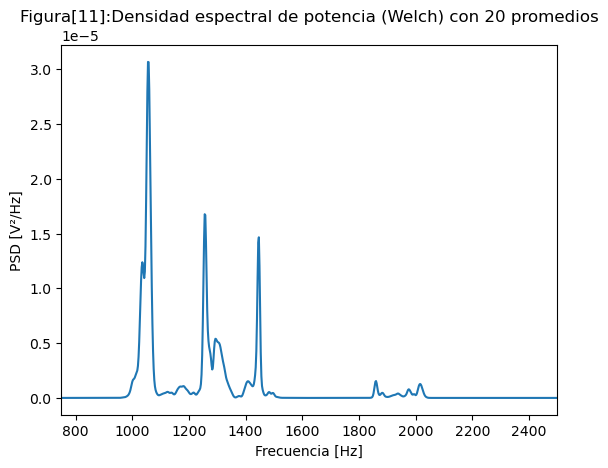

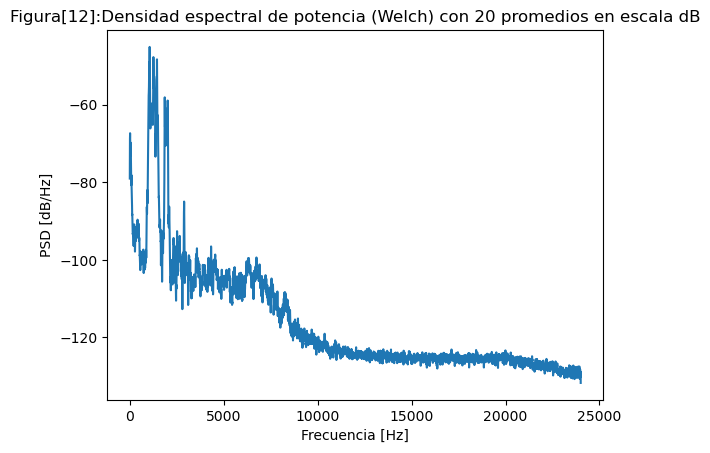

In [8]:
cpcucaracha=20 #cantidad de promedio
npersegcucaracha=wav_data.shape[0] // cpcucaracha
print(npersegcucaracha)
nfftcucaracha=3*npersegcucaracha
win='hann'
tWCuca,WCuca=sig.welch(wav_data,fs=fs_audio,window=win,nperseg=npersegcucaracha,nfft=nfftcucaracha)
plt.figure()
plt.plot(tWCuca,(WCuca))
plt.xlim(750,2500)
plt.title("Figura[11]:Densidad espectral de potencia (Welch) con 20 promedios")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWCuca,10*np.log10(WCuca))
plt.title("Figura[12]:Densidad espectral de potencia (Welch) con 20 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show() 

4800


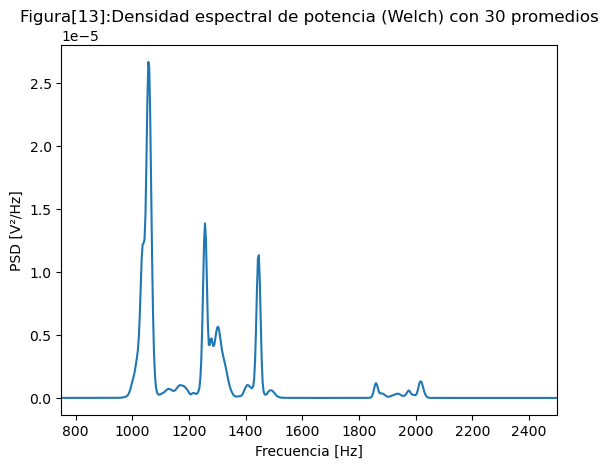

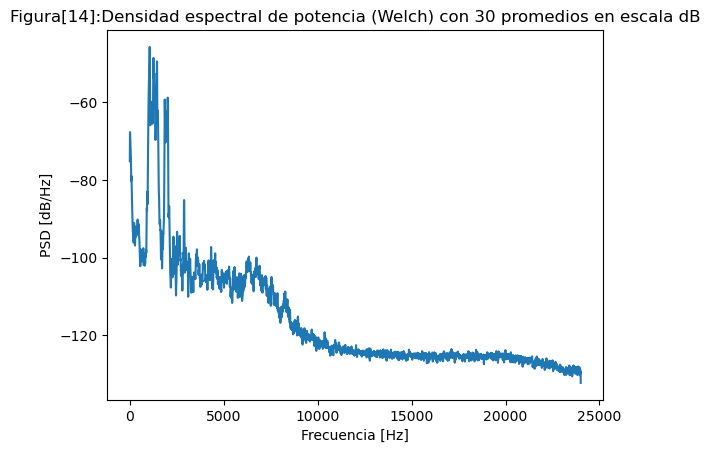

In [9]:
cpcucaracha=30 #cantidad de promedio
npersegcucaracha=wav_data.shape[0] // cpcucaracha
print(npersegcucaracha)
nfftcucaracha=3*npersegcucaracha
win='hann'
tWCuca,WCuca=sig.welch(wav_data,fs=fs_audio,window=win,nperseg=npersegcucaracha,nfft=nfftcucaracha)
plt.figure()
plt.plot(tWCuca,(WCuca))
plt.xlim(750,2500)
plt.title("Figura[13]:Densidad espectral de potencia (Welch) con 30 promedios")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWCuca,10*np.log10(WCuca))
plt.title("Figura[14]:Densidad espectral de potencia (Welch) con 30 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show() 

Se observa nuevamente que los resultados obtenidos coinciden con lo esperado teóricamente: en este tipo de estimaciones existe un compromiso directo entre la cantidad de promedios y la varianza de la estimación. Para analizar tanto el ancho de banda como la cantidad óptima de promedios, se seleccionó un valor intermedio que permitiera mantener una buena correspondencia con el espectro obtenido mediante el método de Blackman–Tukey, adoptando como referencia un rango de 20 a 25 promedios para la representación de la señal PPG.
Es importante destacar que este valor óptimo depende fuertemente de las características de la señal de entrada, y en este caso particular, dicho rango se ajusta adecuadamente a las señales utilizadas en el presente trabajo. 

Text(0.5, 1.0, 'Figura[15]: PPG - Blackman-Tukey')

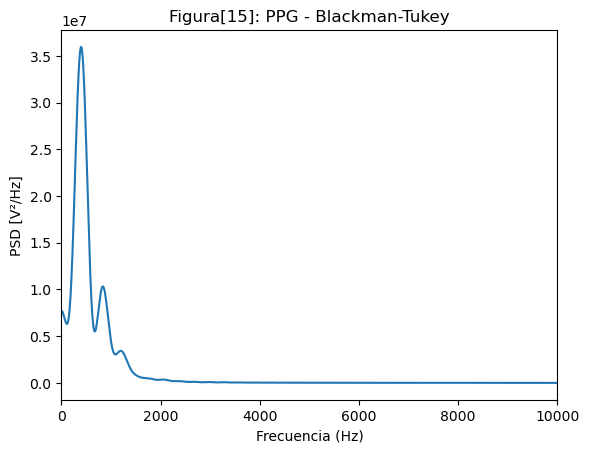

In [54]:
# #blackman-tuky PPG 
#Hago autocorrelacion
PPGxx = ppg - np.mean(ppg)
Rppg=sig.correlate(PPGxx,PPGxx, mode='full')/Nppg
lagsecg = np.arange(-Nppg+1, Nppg)
centerppg = len(Rppg)//2
M= int(1.0 * fs_ppg)
Rppg_seg = Rppg[centerppg-M : centerppg+M+1]
#ventaneo por la ventana triangular
Recgventaneada=Rppg_seg*sig.windows.bartlett(2*M+1)   
#le calculo la FFT
FFTPPG=fft(Recgventaneada,axis=0, n=4*Necg)
plt.figure()
plt.plot(np.abs(FFTPPG))
plt.xlim([0,10000])
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD [V²/Hz]")
plt.title("Figura[15]: PPG - Blackman-Tukey")

cantidad: 1796


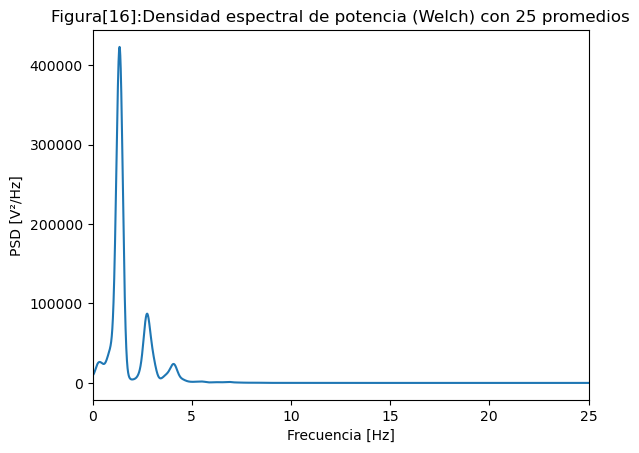

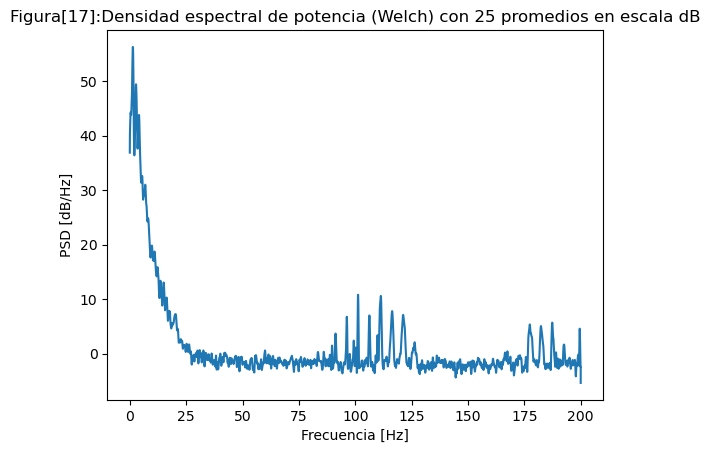

In [11]:
cpppg=25 #cantidad de promedio
npersegPPG=ppg.shape[0] //cpppg
print("cantidad:",npersegPPG)
nfft=100*npersegPPG
win='hann'
tWPPG,WPPG=sig.welch(ppg,fs=fs_ppg,window=win,nperseg=npersegPPG,nfft=nfft)
plt.figure()
plt.plot(tWPPG,(WPPG))
plt.xlim(0,25)
plt.title("Figura[16]:Densidad espectral de potencia (Welch) con 25 promedios")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWPPG,10*np.log10(WPPG))
plt.title("Figura[17]:Densidad espectral de potencia (Welch) con 25 promedios en escala dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show()

Con los valores elegidos los graficos por welch para la ECG y la cucharacha quedaron asi: 

cantidad: 1200


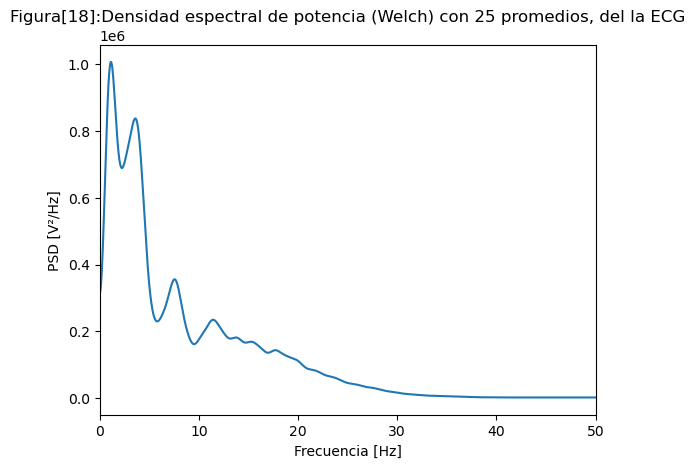

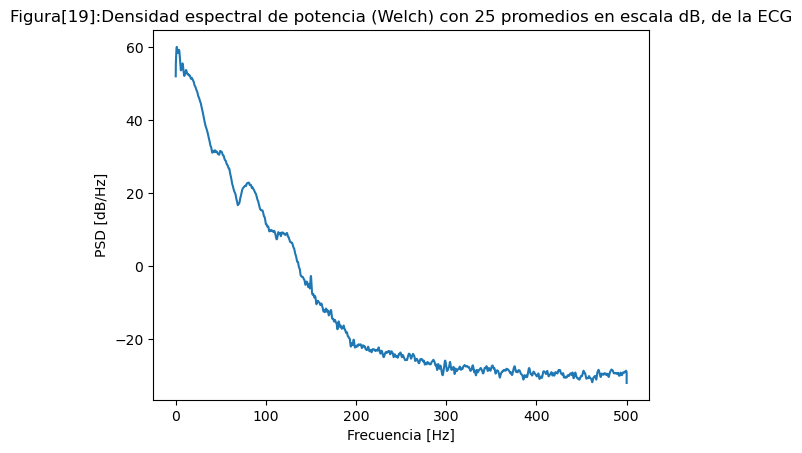

7200


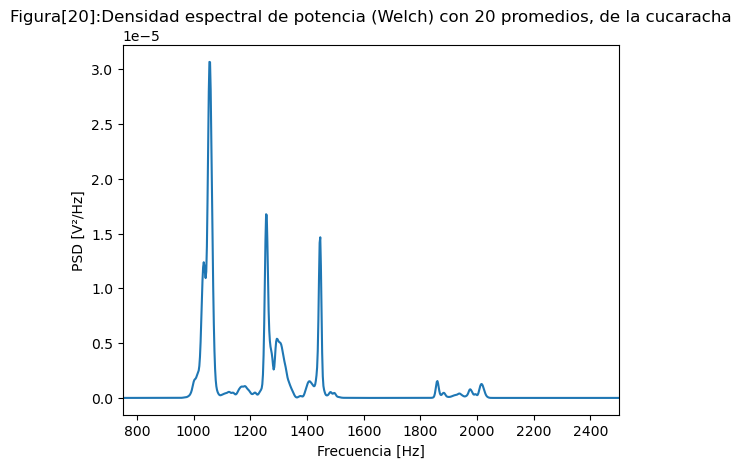

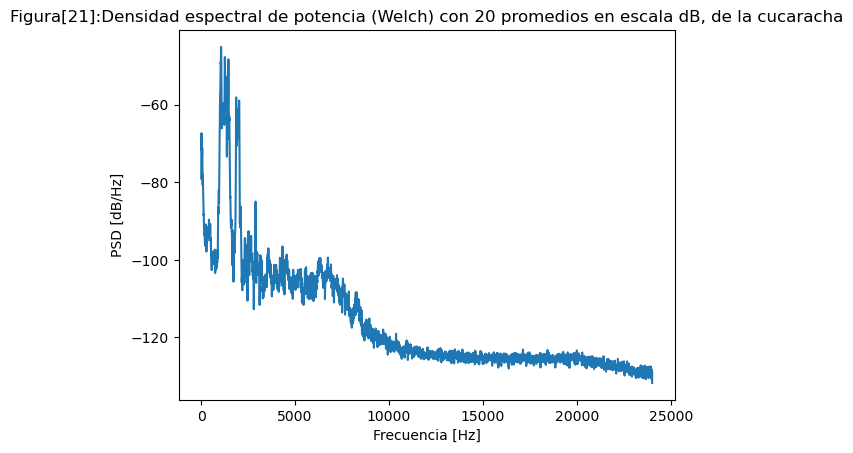

In [12]:
cpECG=25 #cantidad de promedio
npersegECG=ecg_one_lead.shape[0] // cpECG
print("cantidad:",npersegECG)
nfft=100*npersegECG
win='hann'
tWECGSR_ECG,WECGSR_ECG=sig.welch(ecg_one_lead,fs=fs_ecg,window=win,nperseg=npersegECG,nfft=nfft)
plt.figure()
plt.plot(tWECGSR_ECG,(WECGSR_ECG))
plt.xlim(0,50)
plt.title("Figura[18]:Densidad espectral de potencia (Welch) con 25 promedios, del la ECG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWECGSR_ECG,10*np.log10(WECGSR_ECG))
plt.title("Figura[19]:Densidad espectral de potencia (Welch) con 25 promedios en escala dB, de la ECG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show()
cpcucaracha=20 #cantidad de promedio
npersegcucaracha=wav_data.shape[0] // cpcucaracha
print(npersegcucaracha)
nfftcucaracha=3*npersegcucaracha
win='hann'
tWCuca,WCuca=sig.welch(wav_data,fs=fs_audio,window=win,nperseg=npersegcucaracha,nfft=nfftcucaracha)
plt.figure()
plt.plot(tWCuca,(WCuca))
plt.xlim(750,2500)
plt.title("Figura[20]:Densidad espectral de potencia (Welch) con 20 promedios, de la cucaracha")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.show()
plt.figure()
plt.plot(tWCuca,10*np.log10(WCuca))
plt.title("Figura[21]:Densidad espectral de potencia (Welch) con 20 promedios en escala dB, de la cucaracha")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.show() 

Como ya tomamos una eleccion entre la varianza y la densidad espectroscopica podemos utilizar la teoria de las ecuaciones (6),7 y 8 para definir nuestro ancho de banda para cada señal, para esto se obtuvieron los siguientes valores. Computacionalmente se calcularon de la siguiente manera y se obtuvieron lo siguientes valores: 


In [48]:
#calculo de varianza acumulada 
reescalado_ECG=WECGSR_ECG*1e-6
dfECG_ECG=np.diff(tWECGSR_ECG)
dfECG_ECG=np.r_[dfECG_ECG, dfECG_ECG[-1]]
mascara=tWECGSR_ECG <= 50
var_acumECG=np.cumsum(reescalado_ECG[mascara]*dfECG_ECG[mascara])
VarnormECG=var_acumECG/var_acumECG[-1] #varianza normalizada
p=0.99
idx = np.searchsorted(VarnormECG, p)  # índice donde la curva ≥ p
BWECG = tWECGSR_ECG[idx]                  # frecuencia de corte (float)
print("Ancho d banda para la ECG:", BWECG)
print("Varianza total para la ECG:", var_acumECG[-1])

Ancho d banda para la ECG: 29.78
Varianza total para la ECG: 7.436524370155533


In [49]:
reescalado=WCuca*1e+5

dfECG=np.diff(tWCuca)
dfECG=np.r_[dfECG, dfECG[-1]]
mascaracuca=tWCuca<=2200
f_cut = tWCuca[mascaracuca]
var_acumECG=np.cumsum(reescalado[mascaracuca]*dfECG[mascaracuca])
VarnormECG=var_acumECG/var_acumECG[-1] #varianza normalizada
p=0.99
idx = np.searchsorted(VarnormECG, p)  # índice donde la curva ≥ p
Bcuca =  f_cut[idx]                # frecuencia de corte (float)
print("Ancho d banda de la cucaracha:", Bcuca)
print("Varianza total de la cucaracha:", var_acumECG[-1])

Ancho d banda de la cucaracha: 2013.3333333333335
Varianza total de la cucaracha: 183.53240991111994


In [50]:
reescalado_PPG=WPPG*1e-6
dfECG_PPG=np.diff(tWPPG)
dfECG_PPG=np.r_[dfECG_PPG, dfECG_PPG[-1]]
mascara=tWPPG <= 50
var_acumPPG=np.cumsum(reescalado_PPG[mascara]*dfECG_PPG[mascara])
VarnormECG=var_acumPPG/var_acumPPG[-1] #varianza normalizada
p=0.99
idx = np.searchsorted(VarnormECG, p)  # índice donde la curva ≥ p
BWPPG = tWPPG[idx]                  # frecuencia de corte (float)
print("Ancho d banda de la PPG:", BWPPG)
print("Varianza total de la PPG:", var_acumPPG[-1])

Ancho d banda de la PPG: 5.371937639198218
Varianza total de la PPG: 0.27106575765157154


Del análisis realizado se observa que tanto la varianza como el ancho de banda en el caso de La Cucaracha son significativamente mayores que en las señales de ECG y PPG.
Este resultado puede explicarse por dos posibles razones: en primer lugar, porque las frecuencias presentes en la canción concentran una mayor cantidad de energía dentro del rango analizado; y en segundo lugar, podría deberse a alguna diferencia en la implementación del código o en los parámetros utilizados para el cálculo espectral.
En cualquier caso, el comportamiento observado resulta coherente con el hecho de que las señales musicales presentan una composición espectral más amplia y compleja que las señales fisiológicas analizadas. Adicionalmente pudimos encontrar una frecuencia de corte para cada uno de nuestros graficos obteniendo lo siguiente: 

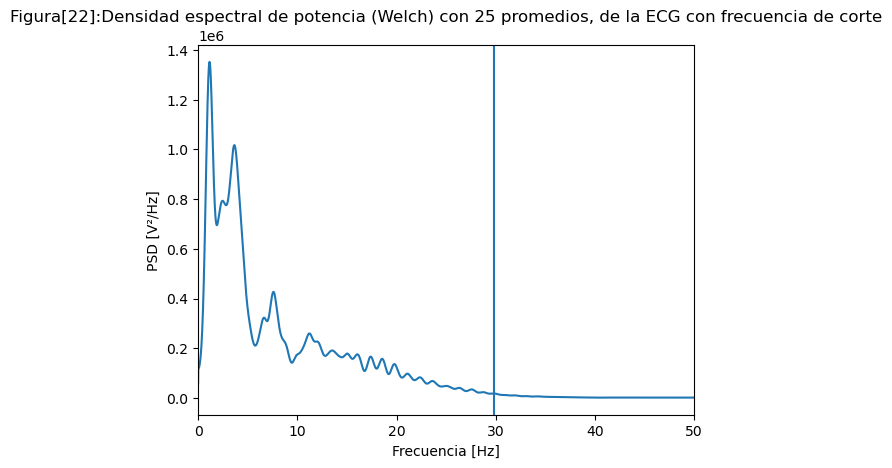

In [47]:
plt.figure()
plt.plot(tWECGSR_ECG,(WECGSR_ECG))
plt.xlim(0,50)
plt.title("Figura[22]:Densidad espectral de potencia (Welch) con 25 promedios, de la ECG con frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.axvline(BWECG)
plt.show()

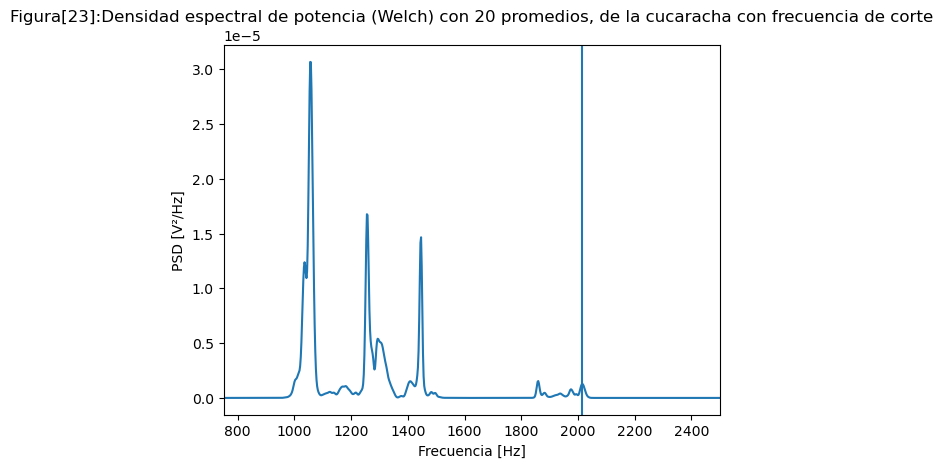

In [17]:
plt.figure()
plt.plot(tWCuca,(WCuca))
plt.xlim(750,2500)
plt.title("Figura[23]:Densidad espectral de potencia (Welch) con 20 promedios, de la cucaracha con frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.axvline(Bcuca)
plt.show()

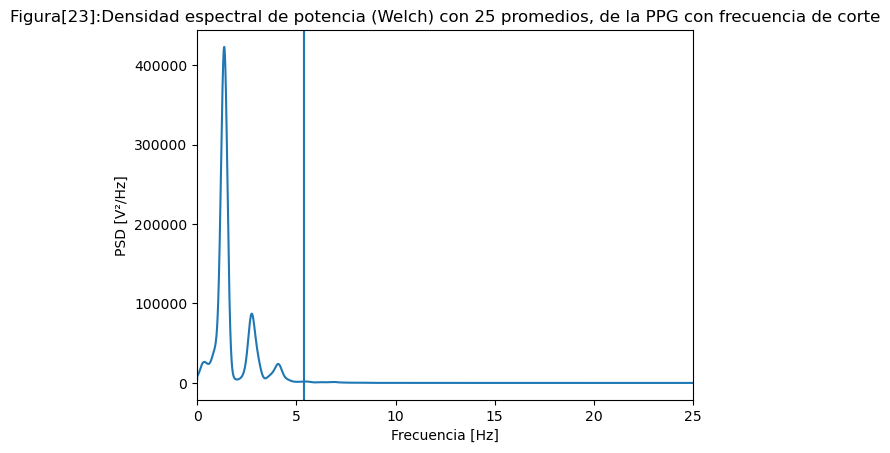

In [18]:
plt.figure()
plt.plot(tWPPG,(WPPG))
plt.xlim(0,25)
plt.title("Figura[23]:Densidad espectral de potencia (Welch) con 25 promedios, de la PPG con frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.axvline(BWPPG)
plt.show()

### Conclusiones


Quedó claro que Welch (con ventana Hann) y Blackman–Tukey (con ventana Bartlett en retardo) entregan visiones complementarias del espectro: 
B–T resaltó los picos y valles porque ventanea la autocorrelación, mientras que Welch redujo mucho la varianza a costa de perder resolución cuando aumentamos la cantidad de promedios. En nuestros datos, la ECG y la PPG concentran potencia en bajas frecuencias y arrojaron anchos de banda de 29.78 Hz y 5.37 Hz, respectivamente, coherentes con la realidad. 
En audio observamos energía distribuida en kHz y un valor de 2013.33 Hz que, por cómo aparece el espectro, probablemente corresponda a la frecuencia fundamental del silbido más que a un “ancho”.
En suma, usaría Welch cuando priorizamos una estimación estable con baja varianza, y Blackman–Tukey cuando necesitamos distinguir picos estrechos y la resolución espectral manda.

### Autoevaluación del aprendizaje


Autoevaluación del aprendizaje

Indicar una opción:

Resolví la tarea, pero tengo dudas, del bonus






Responder:
¿Qué aprendiste al hacer esta tarea? 
¿Qué te quedó claro? 
¿Qué te sigue costando? 

Indicar si se utilizó IA:
Sí, usé chatGPT.
En caso afirmativo, indicar una opción o varias:
Escritura: Me ayudó a mejorar la coherencia y la cohesión de mis textos, además de corregir faltas de ortografía, ya que en este editor de texto no cuento con las líneas rojas que me indiquen si escribí algo mal. Generalmente lo utilizo con ese propósito.